# Hospital Readmission Project — Exploratory Data Analysis (EDA)

This notebook explores patterns, distributions, and relationships within the hospital readmission dataset to uncover clinically relevant insights and support downstream statistical analysis.

In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "/drive/hospital-readmission-project/data/cleaned_hospital_data.csv"
)

## Dataset Overview

This section provides an initial understanding of the cleaned dataset structure and key healthcare variables before conducting deeper analysis.

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Hospital Readmission Distribution

Hospital readmission is a major healthcare quality indicator. This analysis explores the distribution of patient readmission outcomes within the dataset.

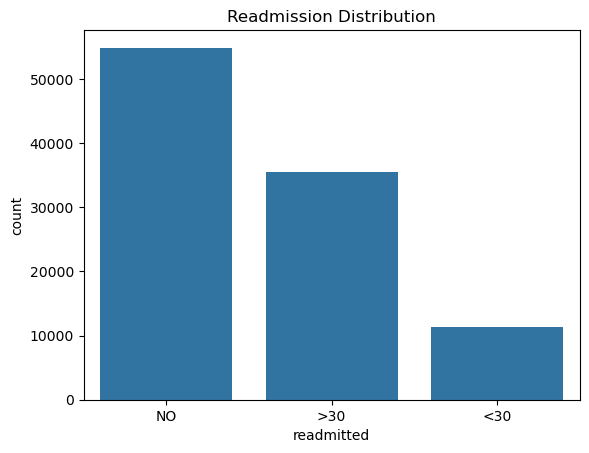

In [4]:
sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Readmission Distribution")

plt.show()

### Insight

A considerable proportion of patients experienced hospital readmission, emphasizing the importance of identifying clinical and operational factors associated with repeated admissions.

## Length of Stay Distribution

Length of hospital stay is an important indicator of clinical severity and healthcare resource utilization.

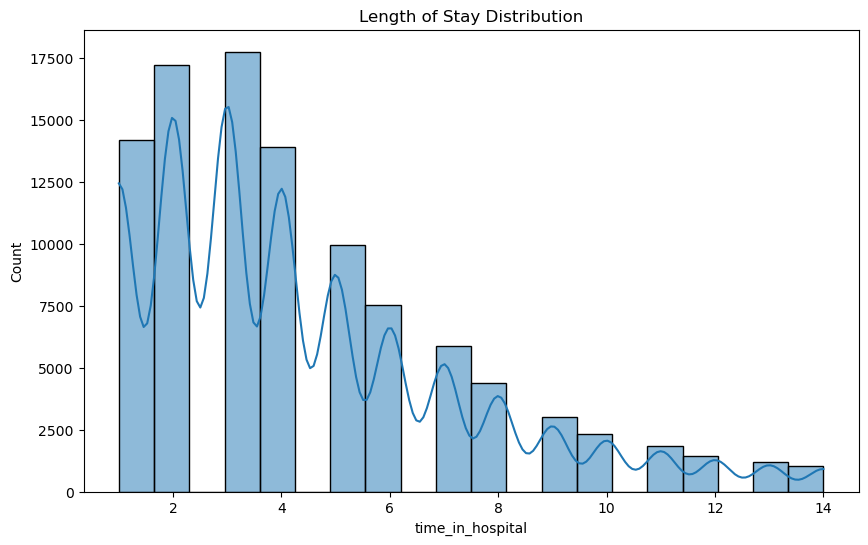

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="time_in_hospital",
    bins=20,
    kde=True
)
plt.title("Length of Stay Distribution")
plt.show()

### Insight

Most patients experienced relatively short hospital stays, while a smaller group required prolonged hospitalization, potentially indicating increased clinical complexity.

## Hospital Stay Duration by Readmission Status

This analysis examines whether hospital stay duration differs across patient readmission categories.

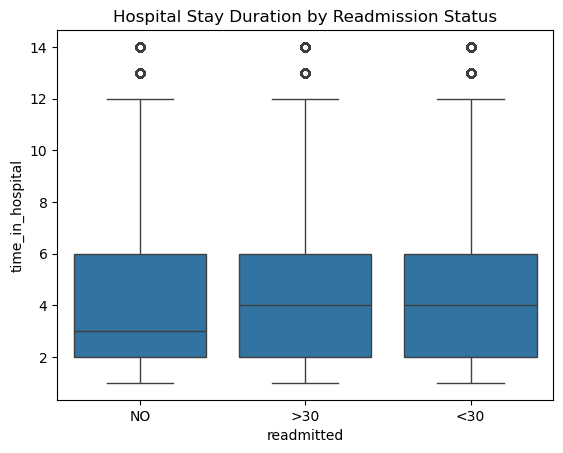

In [13]:
sns.boxplot(
    data=df,
    x="readmitted",
    y="time_in_hospital"
)
plt.title("Hospital Stay Duration by Readmission Status")
plt.show()

### Insight

Patients with readmission events appear to demonstrate longer hospital stays on average, which may reflect more severe or complex clinical conditions.

## Medication Count and Readmission

Medication volume may serve as an indirect indicator of patient complexity and chronic disease burden.

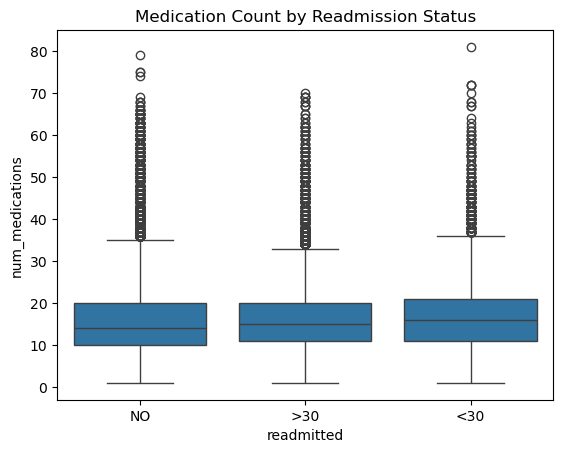

In [14]:
sns.boxplot(
    data=df,
    x="readmitted",
    y="num_medications"
)
plt.title("Medication Count by Readmission Status")
plt.show()

### Insight

Patients with higher medication counts may represent more clinically complex cases, potentially increasing the likelihood of hospital readmission.

## Correlation Analysis

Correlation analysis helps identify relationships between numerical healthcare variables and uncover potential analytical patterns.

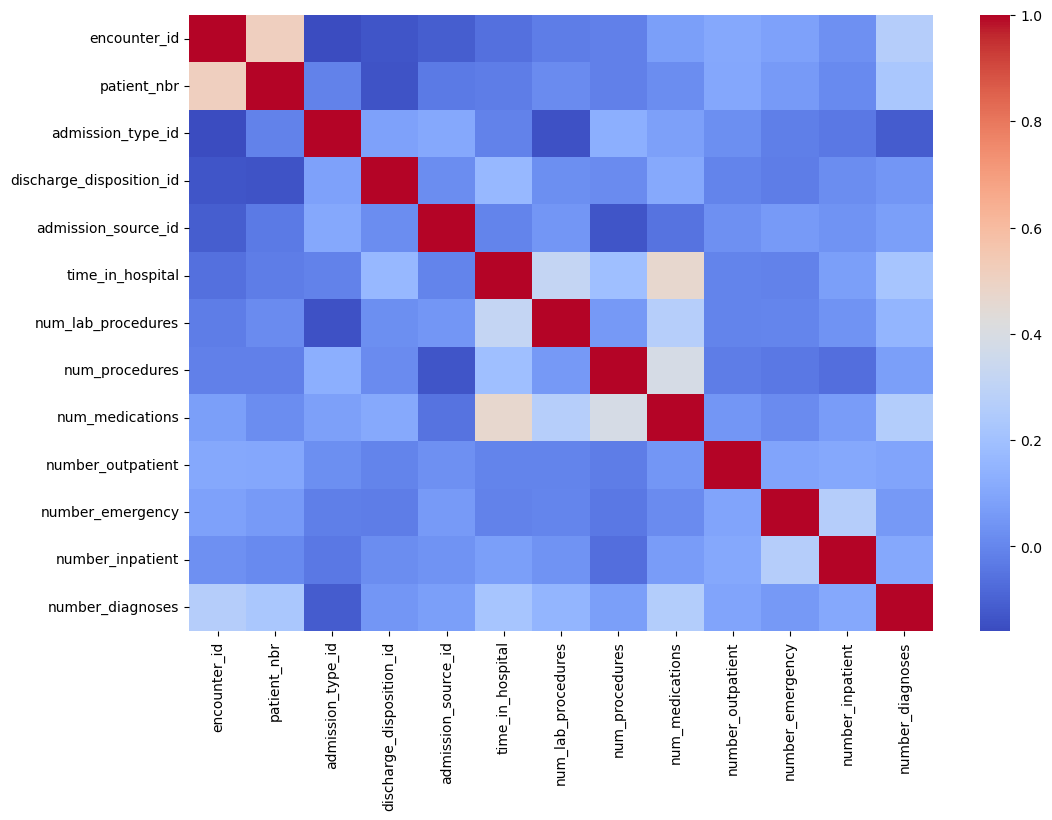

In [8]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.show()

### Insight

Most numerical variables demonstrate weak-to-moderate correlations, suggesting that patient outcomes are influenced by multiple interacting healthcare factors.

## Top Medical Specialties

Different medical specialties contribute differently to hospital admissions and patient management patterns.

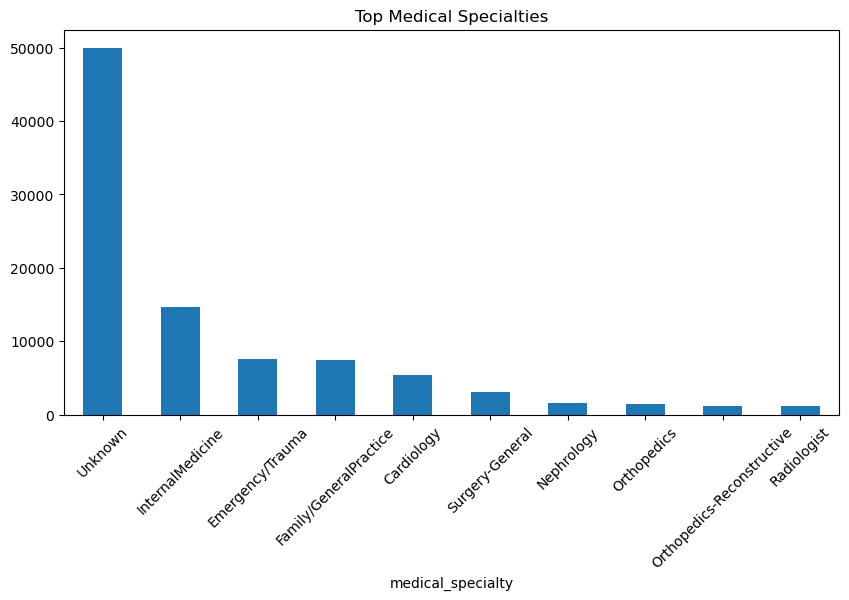

In [15]:
top_specialties = (
    df["medical_specialty"]
    .value_counts()
    .head(10)
)

top_specialties.plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=45)

plt.title("Top Medical Specialties")

plt.show()

### Insight

A small number of medical specialties account for the majority of patient encounters, reflecting common areas of healthcare demand within the dataset.

## Readmission Patterns Across Age Groups

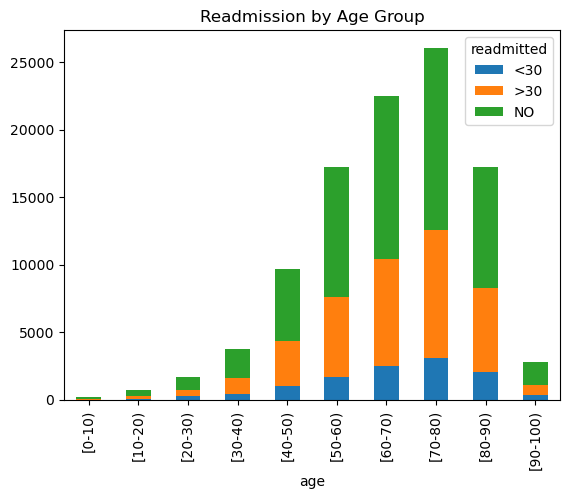

In [9]:
pd.crosstab(df["age"], df["readmitted"]).plot(kind="bar", stacked=True)

plt.title("Readmission by Age Group")

plt.show()

### Insight

Older patient groups appear to experience higher readmission frequencies, potentially reflecting increased chronic disease prevalence and healthcare utilization.

# Key EDA Findings

- Hospital readmission remains common across multiple patient groups
- Older patients represent the largest proportion of hospital admissions
- Longer hospital stays may be associated with increased readmission risk
- Higher medication counts may reflect greater clinical complexity
- Patient outcomes appear to be influenced by multiple interacting healthcare variables
- Several analytical patterns identified during EDA may support future predictive modeling